In [15]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn import 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the updated dataset
df = pd.read_csv("updated_counts_severity_dataset.csv")

# Ensure no missing values in the target column
df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
df["lyrics"].fillna("", inplace=True)

# Define features for analysis
category_count_features = [
    "violence_content_count", "drug_content_count", "hate_speech_content_count", 
    "profanity_content_count", "mental_slurs_content_count", "religious_slurs_content_count", 
    "racial_slurs_content_count", "sexual_content_content_count"
]
category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]
numerical_features = [
    "acousticness", "danceability", "energy", "instrumentalness", 
    "loudness", "speechiness", "tempo", "valence"
]

# Combine all features
all_features = category_count_features + category_severity_features + numerical_features
X_numerical = df[all_features]
y = df["explicit"]  # Target variable


In [3]:
# Convert lyrics to TF-IDF features
tfidf = TfidfVectorizer(max_features=5000)  # Use the top 5000 most important words
X_text = tfidf.fit_transform(df["lyrics"])

# Combine TF-IDF text features with numerical features
X_combined = hstack([X_text, X_numerical])  # Horizontally stack features


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y)


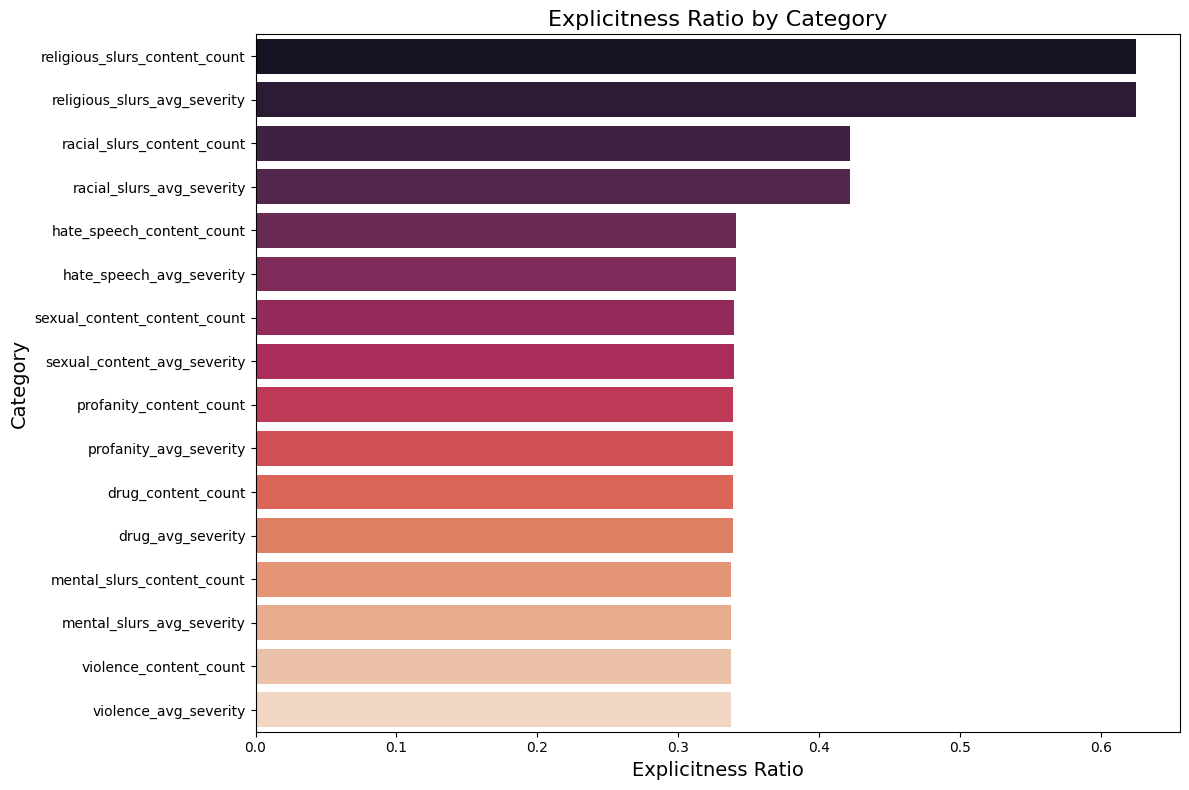

In [5]:
# Calculate explicitness ratios for each feature
category_ratios = {}
for category in category_count_features + category_severity_features:
    ratio = df[df[category] > 0]["explicit"].mean()
    category_ratios[category] = ratio

# Convert results to a DataFrame for visualization
category_ratios_df = pd.DataFrame({
    "Category": category_ratios.keys(),
    "Explicit Ratio": category_ratios.values()
}).sort_values(by="Explicit Ratio", ascending=False)

# Plot explicitness ratios
plt.figure(figsize=(12, 8))
sns.barplot(data=category_ratios_df, x="Explicit Ratio", y="Category", palette="rocket")
plt.title("Explicitness Ratio by Category", fontsize=16)
plt.xlabel("Explicitness Ratio", fontsize=14)
plt.ylabel("Category", fontsize=14)
plt.tight_layout()
plt.show()


Random Forest Accuracy: 0.8410123296560675
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.93      0.89      1027
         1.0       0.82      0.67      0.74       514

    accuracy                           0.84      1541
   macro avg       0.83      0.80      0.81      1541
weighted avg       0.84      0.84      0.84      1541



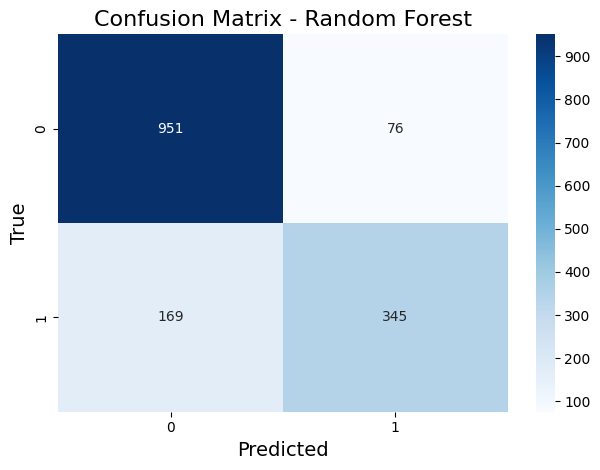

In [6]:
# Train Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# Plot confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.tight_layout()
plt.show()


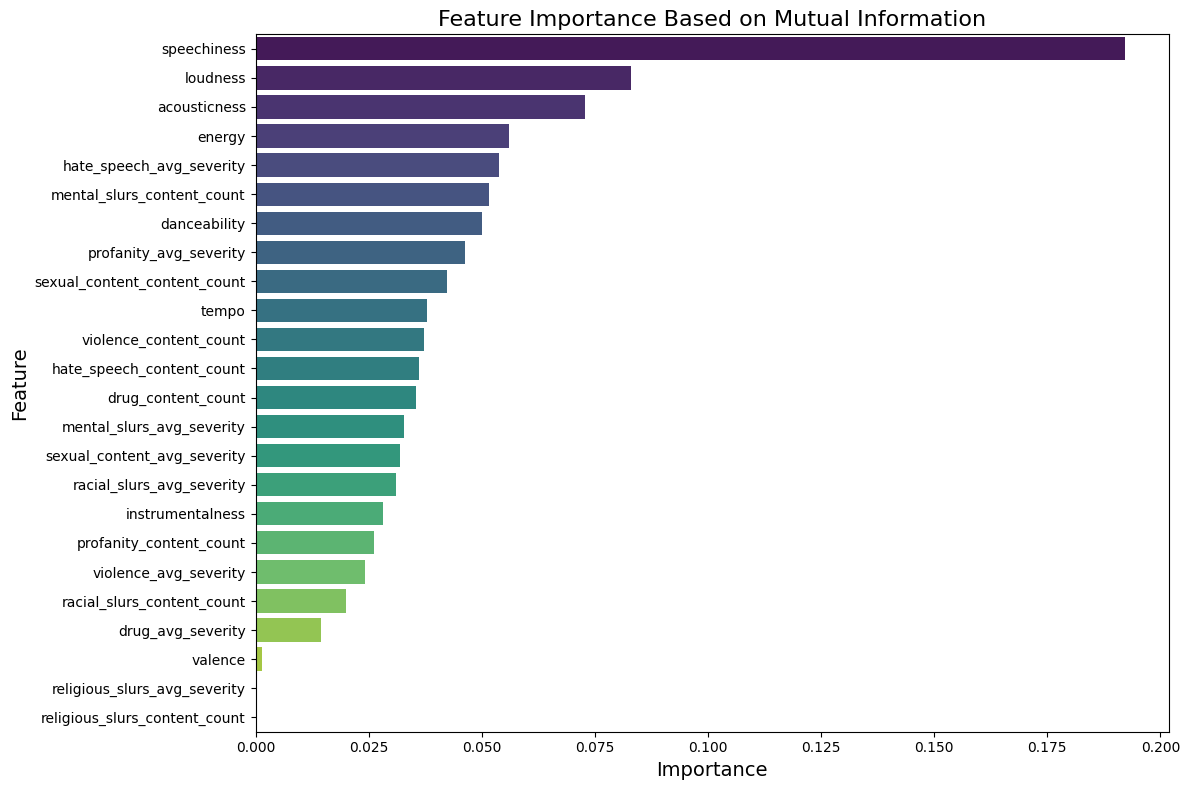

In [7]:
# Calculate mutual information for feature importance
mutual_info = mutual_info_classif(X_numerical, y, random_state=42)
feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": mutual_info
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance Based on Mutual Information", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()



--- Severity Threshold: 0.2 ---
Category: violence_avg_severity
  Explicit: 32.0
  Non-Explicit: 7.0
  Explicitness Ratio: 0.8205
Category: drug_avg_severity
  Explicit: 35.0
  Non-Explicit: 15.0
  Explicitness Ratio: 0.7000
Category: hate_speech_avg_severity
  Explicit: 300.0
  Non-Explicit: 34.0
  Explicitness Ratio: 0.8982
Category: profanity_avg_severity
  Explicit: 235.0
  Non-Explicit: 31.0
  Explicitness Ratio: 0.8835
Category: mental_slurs_avg_severity
  Explicit: 72.0
  Non-Explicit: 13.0
  Explicitness Ratio: 0.8471
Category: religious_slurs_avg_severity
  Explicit: 47.0
  Non-Explicit: 34.0
  Explicitness Ratio: 0.5802
Category: racial_slurs_avg_severity
  Explicit: 301.0
  Non-Explicit: 118.0
  Explicitness Ratio: 0.7184
Category: sexual_content_avg_severity
  Explicit: 148.0
  Non-Explicit: 26.0
  Explicitness Ratio: 0.8506

--- Severity Threshold: 0.4 ---
Category: violence_avg_severity
  Explicit: 5.0
  Non-Explicit: 1.0
  Explicitness Ratio: 0.8333
Category: drug_avg_s

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


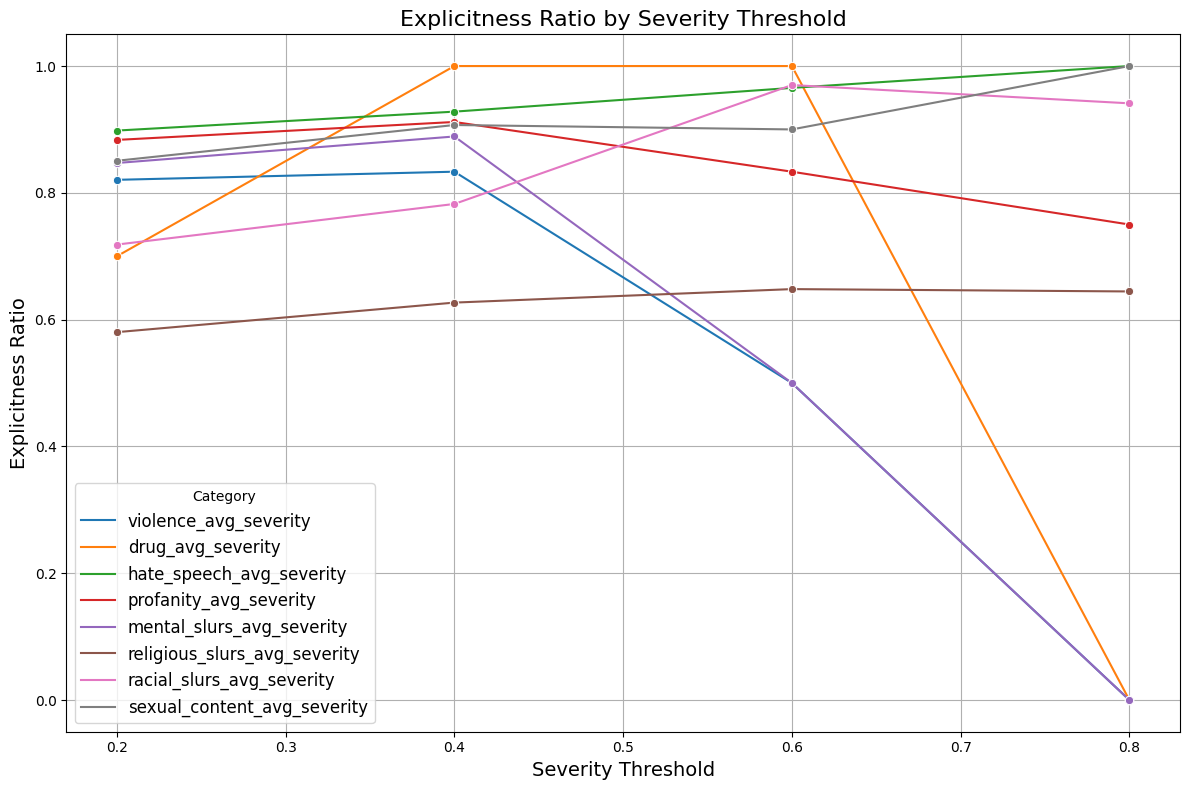

In [8]:
# Define severity thresholds to analyze
severity_thresholds = [0.2, 0.4, 0.6, 0.8]  
severity_ratios = {category: [] for category in category_severity_features}
severity_counts = {category: [] for category in category_severity_features}

# Calculate explicitness ratios and counts for each threshold
for threshold in severity_thresholds:
    print(f"\n--- Severity Threshold: {threshold} ---")
    for category in category_severity_features:
        filtered_songs = df[df[category] > threshold]
        explicit_count = filtered_songs["explicit"].sum()
        non_explicit_count = len(filtered_songs) - explicit_count
        
        if len(filtered_songs) > 0:
            ratio = explicit_count / len(filtered_songs)
        else:
            ratio = 0
        
        severity_ratios[category].append(ratio)
        severity_counts[category].append((explicit_count, non_explicit_count))
        
        print(f"Category: {category}")
        print(f"  Explicit: {explicit_count}")
        print(f"  Non-Explicit: {non_explicit_count}")
        print(f"  Explicitness Ratio: {ratio:.4f}")

# Convert severity ratios to DataFrame for visualization
severity_ratios_df = pd.DataFrame(severity_ratios, index=severity_thresholds).reset_index()
severity_ratios_df = severity_ratios_df.melt(id_vars="index", var_name="Category", value_name="Explicitness Ratio")
severity_ratios_df.rename(columns={"index": "Severity Threshold"}, inplace=True)

# Plot severity threshold analysis
plt.figure(figsize=(12, 8))
sns.lineplot(data=severity_ratios_df, x="Severity Threshold", y="Explicitness Ratio", hue="Category", marker="o")
plt.title("Explicitness Ratio by Severity Threshold", fontsize=16)
plt.xlabel("Severity Threshold", fontsize=14)
plt.ylabel("Explicitness Ratio", fontsize=14)
plt.legend(title="Category", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
#Make predictions based on features only
# Load the updated dataset
df = pd.read_csv("updated_counts_severity_dataset.csv")

# Ensure no missing values in the target column
df = df.dropna(subset=["explicit"])

# Fill missing lyrics with empty strings
df["lyrics"] = df["lyrics"].fillna("")

category_severity_features = [
    "violence_avg_severity", "drug_avg_severity", "hate_speech_avg_severity", 
    "profanity_avg_severity", "mental_slurs_avg_severity", "religious_slurs_avg_severity", 
    "racial_slurs_avg_severity", "sexual_content_avg_severity"
]

X_severity = df[category_severity_features]
y = df["explicit"]

Random Forest Accuracy: 0.7118754055807917
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.99      0.82      1027
         1.0       0.86      0.16      0.27       514

    accuracy                           0.71      1541
   macro avg       0.78      0.57      0.55      1541
weighted avg       0.76      0.71      0.64      1541



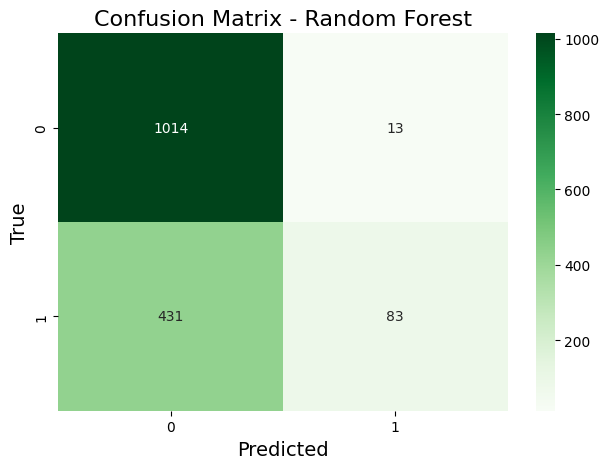

In [19]:
# Train data only based on avg severity
# Split data into training and testing sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_severity, y, test_size=0.2, random_state=42, stratify=y)
# Train Random Forest
rf_model_s = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_s.fit(X_train_s, y_train_s)

# Evaluate Random Forest
y_pred_rf_s = rf_model_s.predict(X_test_s)
print("Random Forest Accuracy:", accuracy_score(y_test_s, y_pred_rf_s))
print("Classification Report:\n", classification_report(y_test_s, y_pred_rf_s))

# Plot confusion matrix
rf_cm = confusion_matrix(y_test_s, y_pred_rf_s)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.tight_layout()
plt.show()


In [21]:
#Train data based on acg severity * number
df.columns

Index(['artist_all', 'artist_base', 'rank', 'song', 'year', 'artist_featured',
       'song_clean', 'artist_clean', 'lyrics', 'acousticness', 'danceability',
       'energy', 'explicit', 'instrumentalness', 'key', 'liveness', 'loudness',
       'mode', 'popularity', 'release_date', 'speechiness', 'tempo',
       'time_signature', 'valence', 'duration_min', 'num_words',
       'words_per_sec', 'num_uniq_words', 'decade', 'uniq_ratio', 'artist',
       'link', 'text', 'id', 'type', 'uri', 'track_href', 'analysis_url',
       'duration_ms', 'violence_content_count', 'violence_avg_severity',
       'drug_content_count', 'drug_avg_severity', 'hate_speech_content_count',
       'hate_speech_avg_severity', 'profanity_content_count',
       'profanity_avg_severity', 'mental_slurs_content_count',
       'mental_slurs_avg_severity', 'religious_slurs_content_count',
       'religious_slurs_avg_severity', 'racial_slurs_content_count',
       'racial_slurs_avg_severity', 'sexual_content_content_cou

In [25]:
content_count_features = ['violence_content_count', 'drug_content_count', 'hate_speech_content_count', 'profanity_content_count', 
                         'mental_slurs_content_count', 'religious_slurs_content_count', 'racial_slurs_content_count', 'sexual_content_content_count']

Random Forest Accuracy: 0.7099286177806619
Classification Report:
               precision    recall  f1-score   support

         0.0       0.70      0.98      0.82      1027
         1.0       0.84      0.16      0.27       514

    accuracy                           0.71      1541
   macro avg       0.77      0.57      0.54      1541
weighted avg       0.75      0.71      0.64      1541



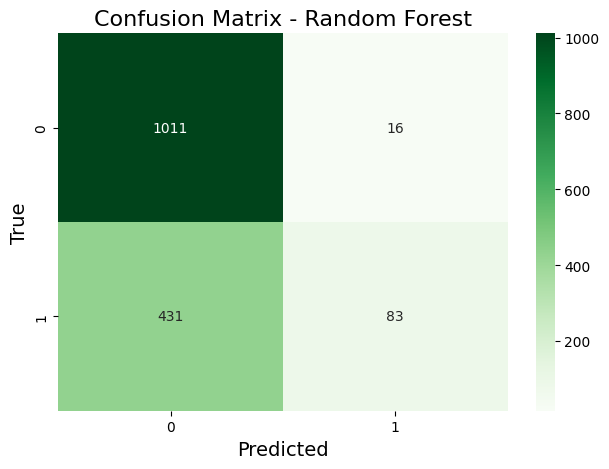

In [28]:
X_severity_count = df[category_severity_features+content_count_features]
y = df["explicit"]
# Train data only based on avg severity
# Split data into training and testing sets
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_severity_count, y, test_size=0.2, random_state=42, stratify=y)
# Train Random Forest
rf_model_s = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_s.fit(X_train_s, y_train_s)

# Evaluate Random Forest
y_pred_rf_s = rf_model_s.predict(X_test_s)
print("Random Forest Accuracy:", accuracy_score(y_test_s, y_pred_rf_s))
print("Classification Report:\n", classification_report(y_test_s, y_pred_rf_s))

# Plot confusion matrix
rf_cm = confusion_matrix(y_test_s, y_pred_rf_s)
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.tight_layout()
plt.show()